In [10]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv("../DATA/Anthocyanin_with_Illumination__231125-311225.csv")
df.head(1)

,DATE,Cultivar Name,Lettuce color,catalog id,Illumination,Chlorophyll interference,Anthocyanin
0,05.12.25,Gauguin RZ,RED,R1,White+Blue LED,0.027,0.689


In [12]:
df_red=df[df['Lettuce color'] == 'RED']
df_green=df[df['Lettuce color'] == 'GREEN']

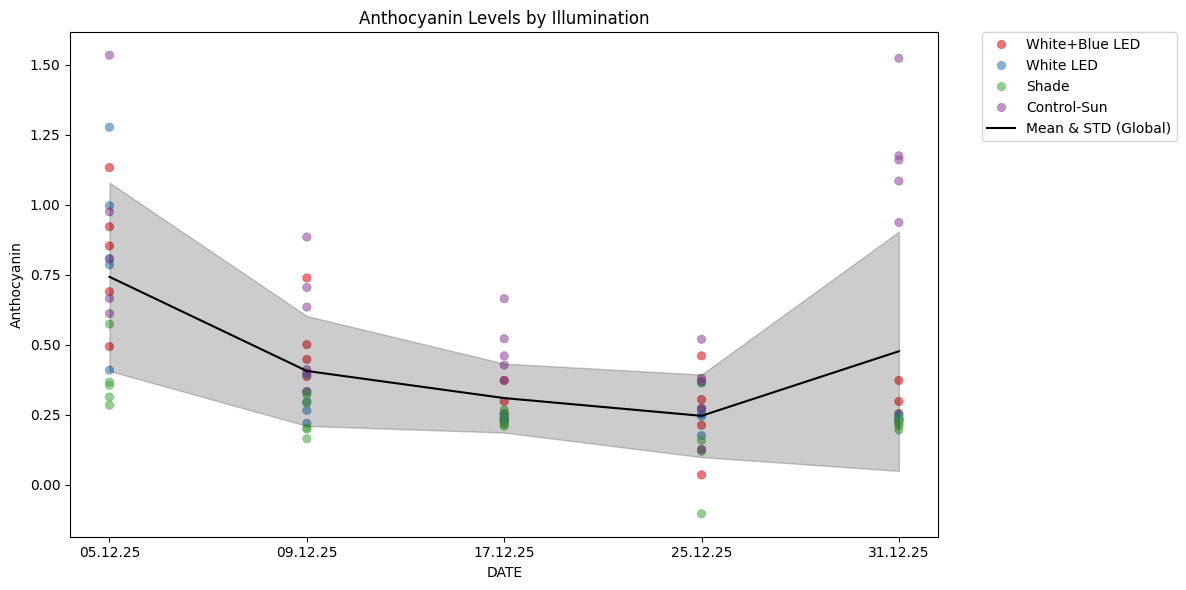

In [13]:


# 1. Create the figure
plt.figure(figsize=(12, 6))

# 2. Draw the Scatter Plot with Seaborn
# 'hue' handles the colors and creates the legend automatically
sns.scatterplot(
    data=df_red, 
    x='DATE', 
    y='Anthocyanin', 
    hue='Illumination', 
    palette='Set1', 
    alpha=0.6,
    edgecolor=None
)

# 3. Draw the Mean + STD line on top
sns.lineplot(
    data=df_red, 
    x='DATE', 
    y='Anthocyanin', 
    color='black', 
    errorbar='sd', 
    label='Mean & STD (Global)'
)

# 4. Move the legend so it doesn't cover the data
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.title('Anthocyanin Levels by Illumination')
plt.tight_layout() # Prevents the legend from being cut off
plt.show()

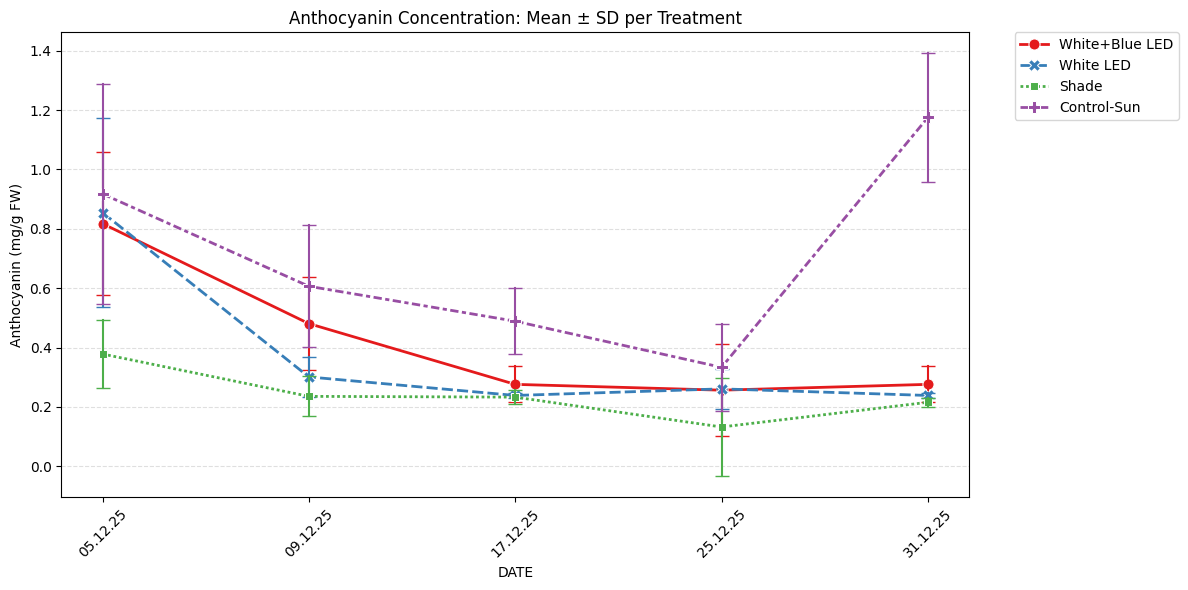

In [18]:


plt.figure(figsize=(12, 6))

# Use err_kws to pass capsize to the underlying errorbar function
sns.lineplot(
    data=df_red, 
    x='DATE', 
    y='Anthocyanin', 
    hue='Illumination', 
    style='Illumination',
    markers=True,         
    errorbar='sd',        
    err_style='bars',     
    err_kws={'capsize': 5},  # This is the fix!
    palette='Set1',
    linewidth=2,
    markersize=8
)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title('Anthocyanin Concentration: Mean ± SD per Treatment')
plt.ylabel('Anthocyanin (mg/g FW)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

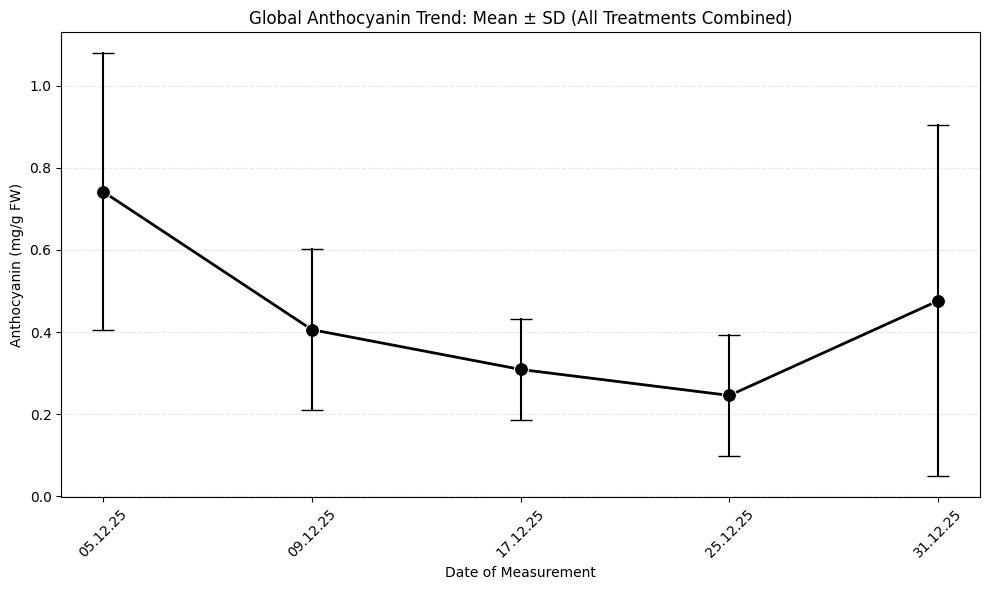

In [20]:


# 1. Create the figure
plt.figure(figsize=(10, 6))

# 2. Draw the Global Error Bar Plot
# By removing 'hue', we force Seaborn to aggregate ALL treatments together
sns.lineplot(
    data=df_red, 
    x='DATE', 
    y='Anthocyanin', 
    marker='o',           # Adds a single dot for the global mean
    errorbar='sd',        # Calculates the SD of all samples on that date
    err_style='bars',     # Shows the "I" bars
    err_kws={'capsize': 8}, 
    color='black',        # A neutral color for global data
    linewidth=2,
    markersize=10
)

# 3. Formatting
plt.title('Global Anthocyanin Trend: Mean ± SD (All Treatments Combined)')
plt.ylabel('Anthocyanin (mg/g FW)')
plt.xlabel('Date of Measurement')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# 1. Group by DATE
# 2. Pick the column 'Anthocyanin'
# 3. Aggregate by 'mean' and 'std'
stats_df = df_red.groupby('DATE')['Anthocyanin'].agg(['mean', 'std']).reset_index()

# Display the result
print(stats_df)

       DATE     mean       std
0  05.12.25  0.74195  0.336214
1  09.12.25  0.40590  0.196255
2  17.12.25  0.30910  0.123152
3  25.12.25  0.24575  0.147413
4  31.12.25  0.47630  0.427102


In [15]:
# Group by two columns instead of one
detailed_stats = df_red.groupby(['DATE', 'Illumination'])['Anthocyanin'].agg(['mean', 'std']).reset_index()

# This gives you a row for every unique Date-Illumination combination
# Sort by Illumination alphabetically
detailed_stats = detailed_stats.sort_values(by=['Illumination','DATE' ])

# Display the sorted result
print(detailed_stats)

        DATE    Illumination    mean       std
0   05.12.25     Control-Sun  0.9176  0.371614
4   09.12.25     Control-Sun  0.6064  0.205271
8   17.12.25     Control-Sun  0.4888  0.111829
12  25.12.25     Control-Sun  0.3334  0.145806
16  31.12.25     Control-Sun  1.1750  0.215678
1   05.12.25           Shade  0.3782  0.113753
5   09.12.25           Shade  0.2356  0.067211
9   17.12.25           Shade  0.2330  0.024259
13  25.12.25           Shade  0.1324  0.165784
17  31.12.25           Shade  0.2156  0.015469
2   05.12.25       White LED  0.8546  0.317506
6   09.12.25       White LED  0.3010  0.066087
10  17.12.25       White LED  0.2386  0.008989
14  25.12.25       White LED  0.2608  0.068247
18  31.12.25       White LED  0.2386  0.008989
3   05.12.25  White+Blue LED  0.8174  0.241156
7   09.12.25  White+Blue LED  0.4806  0.157155
11  17.12.25  White+Blue LED  0.2760  0.060651
15  25.12.25  White+Blue LED  0.2564  0.154046
19  31.12.25  White+Blue LED  0.2760  0.060651


c:\myProjects\phenomobile\.venv\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1388: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


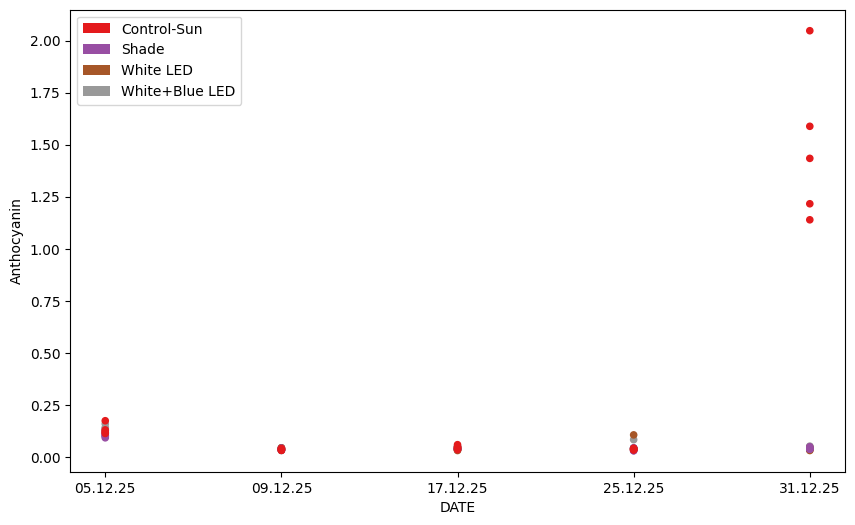

In [16]:
df_green=df[df['Lettuce color'] == 'GREEN']
#plt.figure(figsize=(10, 6))
#df_green.plot.scatter(x='DATE', y='Anthocyanin', title='Anthocyanin level along the dates')

df_green.plot.scatter(x='DATE', y='Anthocyanin', 
        c='Illumination', 
        colormap='Set1',figsize=(10, 6) ,
        sharex=False)          

plt.show()